In [1]:
import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

In [ ]:
USERNAME = 'vinhtrinhcm'   # Thay bằng tài khoản SQL Server của bạn
PASSWORD = 'uIWr%91@mq41%S'   # Thay bằng mật khẩu của bạn

# Cấu hình chuỗi kết nối (Windows Authentication)

connection_url = URL.create(
    "mssql+pyodbc",
    username=USERNAME,
    password=PASSWORD,
    host="45.124.94.158",
    port=1433,
    database="xomdata_dataset",
    query={
        "driver": "ODBC Driver 18 for SQL Server",
        "TrustServerCertificate": "yes",
    },
)

engine = create_engine(connection_url)

try:
    with engine.connect() as conn:
        print("Successfully connected!")
        df = pd.read_sql("SELECT TOP 5 * FROM INFORMATION_SCHEMA.TABLES", conn)
        display(df)
except Exception as e:
    print("Failed to connect:", e)

Successfully connected


,TABLE_CATALOG,TABLE_SCHEMA,TABLE_NAME,TABLE_TYPE
0,xomdata_dataset,fmcg_sales,categories,BASE TABLE
1,xomdata_dataset,fmcg_sales,countries,BASE TABLE
2,xomdata_dataset,fmcg_sales,cities,BASE TABLE
3,xomdata_dataset,fmcg_sales,customers,BASE TABLE
4,xomdata_dataset,fmcg_sales,employees,BASE TABLE


In [3]:
# Lấy danh sách bảng
query_tables = """
SELECT TABLE_SCHEMA, TABLE_NAME 
FROM INFORMATION_SCHEMA.TABLES 
WHERE TABLE_TYPE = 'BASE TABLE'
"""
df_tables = pd.read_sql(query_tables, engine)
df_tables

,TABLE_SCHEMA,TABLE_NAME
0,fmcg_sales,categories
1,fmcg_sales,countries
2,fmcg_sales,cities
3,fmcg_sales,customers
4,fmcg_sales,employees
...,...,...
64,banking,users
65,banking,cards
66,banking,transactions
67,crm_analytics,deals


In [5]:
# list(df_tables['TABLE_NAME'])


In [4]:
pd.set_option('display.max_rows', None)
df_tables

,TABLE_SCHEMA,TABLE_NAME
0,fmcg_sales,categories
1,fmcg_sales,countries
2,fmcg_sales,cities
3,fmcg_sales,customers
4,fmcg_sales,employees
5,fmcg_sales,products
6,fmcg_sales,sales
7,skytrax,airlines
8,skytrax,airports
9,skytrax,airline_reviews


In [5]:
# Lọc các bảng liên quan đến skytrax
df_tables[df_tables['TABLE_SCHEMA'].str.contains('sky', case=False, na=False)]

,TABLE_SCHEMA,TABLE_NAME
7,skytrax,airlines
8,skytrax,airports
9,skytrax,airline_reviews
10,skytrax,airport_reviews
11,skytrax,lounge_reviews
12,skytrax,seat_reviews


In [6]:
# Đọc dữ liệu ra DataFrame
query = "SELECT * FROM skytrax.airlines"
airlines = pd.read_sql(query, engine)

print(f"Tổng số dòng: {len(airlines)}")
airlines.head()


Tổng số dòng: 595


,airline_id,airline_name
0,1,AB Aviation
1,2,AIRDO
2,3,AJet
3,4,ANA All Nippon Airways
4,5,ASKY Airlines


In [7]:
query = "SELECT * FROM skytrax.airports"
airports = pd.read_sql(query, engine)

print(f"Tổng số dòng: {len(airports)}")
airports.head()

Tổng số dòng: 1004


,airport_id,airport_name
0,1,ANR Robinson International
1,2,Aalborg
2,3,Aarhus
3,4,Abbotsford Intl
4,5,Aberdeen


In [8]:
query = "SELECT * FROM skytrax.airline_reviews"
airline_reviews = pd.read_sql(query, engine)

print(f"Tổng số dòng: {len(airline_reviews)}")
airline_reviews.head()

Tổng số dòng: 156323


,review_id,airline_id,verify,date_submitted,date_flown,customer_name,nationality,type_of_traveller,seat_type,aircraft,...,seat_comfort,cabin_staff_service,food_and_beverages,inflight_entertainment,ground_service,wifi_and_connectivity,value_for_money,recommended,review,updated_at
0,1,313,False,2002-01-06,None,Joshua Torres 6,flt. 93,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,I flew Lan Peru on a domestic flight from Lima...,2026-04-03 14:30:19
1,2,313,False,2002-01-06,None,Joshua Torres 6,flt. 93,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,I flew Lan Peru on a domestic flight from Lima...,2026-04-03 14:30:19
2,3,466,False,2002-02-14,None,Cynthia Lee 30,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Skymark is a low-fare airline in Japan. I flow...,2026-04-03 14:30:19
3,4,313,False,2002-03-21,None,Donna Lee 9,thin around 40 about 5'5' dark hair to his sho...,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,I have flown LanPeru into and out of Cuzco man...,2026-04-03 14:30:19
4,5,313,False,2002-03-21,None,Donna Lee 9,thin around 40 about 5'5' dark hair to his sho...,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,I have flown LanPeru into and out of Cuzco man...,2026-04-03 14:30:19


In [9]:
query = "SELECT * FROM skytrax.airport_reviews"
airport_reviews = pd.read_sql(query, engine)

print(f"Tổng số dòng: {len(airport_reviews)}")
airport_reviews.head()

Tổng số dòng: 49505


,review_id,airport_id,verify,date_submitted,date_visit,customer_name,nationality,experience_at_airport,type_of_traveller,queuing_times,terminal_cleanliness,terminal_seating,terminal_signs,food_beverages,airport_shopping,airport_staff,wifi_connectivity,recommended,review,updated_at
0,1,9,False,2022-06-06,2022-03-01,Charles Smith 24,Netherlands,Arrival and Departure,Couple Leisure,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,True,"This 'newish' airport is compact, clean, spaci...",2026-06-20 12:45:42
1,2,8,False,2017-03-05,2017-02-01,Wei Rivera 19,United Kingdom,Arrival and Departure,Business,2.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,True,Abuja airport is closing on 7 March for 6 week...,2026-06-20 12:45:42
2,3,8,False,2016-04-25,2016-04-01,George Rossi 28,Nigeria,Arrival Only,Solo Leisure,1.0,2.0,1.0,5.0,NaN,NaN,1.0,NaN,False,"For starters Abuja airport was super hot, no a...",2026-06-20 12:45:42
3,4,8,False,2012-02-28,None,Emily Scott 2,United Kingdom,None,None,2.0,3.0,NaN,NaN,NaN,1.0,NaN,NaN,False,On arrival as we flew Business Class we were n...,2026-06-20 12:45:42
4,5,8,False,2011-08-08,None,Aisha Brown,United States,None,None,1.0,3.0,NaN,NaN,NaN,1.0,NaN,NaN,False,Abuja international arrivals greets you with a...,2026-06-20 12:45:42


In [10]:
query = "SELECT * FROM skytrax.lounge_reviews"
lounge_reviews = pd.read_sql(query, engine)

print(f"Tổng số dòng: {len(lounge_reviews)}")
lounge_reviews.head()

Tổng số dòng: 5087


,review_id,airline_id,lounge_name,airport,type_of_lounge,type_of_traveller,verify,date_submitted,date_visit,customer_name,...,comfort,cleanliness,bar_and_beverages,catering,washrooms,wifi_connectivity,staff_service,recommended,review,updated_at
0,1,9,JFK Terminal 7,New York JFK Airport,Business Class,Business,True,2024-05-21,2024-05-01,Linda Roberts 16,...,5.0,5.0,4.0,4.0,4.0,5.0,4.0,True,This is a new lounge for Aer Lingus as on prev...,2026-06-20 12:45:41
1,2,9,Aer Lingus,New York JFK Airport,Business Class,Business,True,2023-06-15,2023-06-01,Linda Roberts 16,...,5.0,5.0,4.0,2.0,5.0,5.0,5.0,True,"A small, clean lounge with plenty of seating, ...",2026-06-20 12:45:41
2,3,9,None,London Heathrow Airport,Business Class,Business,False,2023-05-25,2023-05-01,Ronald Lopez 9,...,3.0,3.0,1.0,1.0,3.0,4.0,2.0,False,"While the decor etc is nice, the food is absol...",2026-06-20 12:45:41
3,4,9,Dublin,Dublin Airport,Business Class,Business,True,2020-02-04,2020-01-01,Hassan Nelson 16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,"I would probably rate the lounge as awesome, b...",2026-06-20 12:45:41
4,5,9,Gold Circle,Dublin Airport,Frequent Flyer,None,False,2017-02-15,2017-02-01,Michelle Thompson 23,...,5.0,5.0,5.0,5.0,5.0,5.0,5.0,True,The Gold Circle Lounge in Dublin T2 is a two s...,2026-06-20 12:45:41


In [11]:
query = "SELECT * FROM skytrax.seat_reviews"
seat_reviews = pd.read_sql(query, engine)
print(f"Tổng số dòng: {len(seat_reviews)}")
seat_reviews.head()

Tổng số dòng: 3766


,review_id,airline_id,type_of_traveller,seat_type,aircraft_type,seat_layout,verify,date_submitted,date_flown,customer_name,...,power_supply,viewing_tv_screen,sleep_comfort,sitting_comfort,seat_bed_width,seat_bed_length,seat_privacy,recommended,review,updated_at
0,1,17,Couple Leisure,Economy Class,Boeing 737-800,3x3,True,2023-08-26,2023-08-01,Carol Costa 29,...,2.0,2.0,NaN,NaN,NaN,NaN,NaN,False,The seats on the way to Cancun from Mexico Cit...,2026-06-20 12:45:41
1,2,17,Solo Leisure,Economy Class,Boeing 737-800,3x3,True,2022-03-15,2022-03-01,Laura Patel 28,...,NaN,2.0,NaN,NaN,NaN,NaN,NaN,False,"Seats are hard as a rock, slanting downwards, ...",2026-06-20 12:45:41
2,3,17,Business,Economy Class,Boeing 787-9,3x3x3,True,2019-06-26,2019-06-01,Mary Adams 31,...,4.0,5.0,NaN,NaN,NaN,NaN,NaN,True,It was my first experience on a 9-abreast Drea...,2026-06-20 12:45:41
3,4,17,Family Leisure,Premium Economy,Boeing 737-800,3x3,True,2018-09-29,2018-09-01,Michael Smith 4,...,5.0,5.0,NaN,NaN,NaN,NaN,NaN,True,"Good leg space and recline on AM Plus seats, a...",2026-06-20 12:45:41
4,5,17,Couple Leisure,Economy Class,Boeing 737-800,3x3,True,2018-09-10,2018-09-01,Christopher Smith 3,...,5.0,5.0,NaN,NaN,NaN,NaN,NaN,True,"Main Cabin Seat 24A, window. Good recline, goo...",2026-06-20 12:45:41


In [12]:
df_tables[df_tables['TABLE_SCHEMA'].str.contains('sky', case=False, na=False)]

,TABLE_SCHEMA,TABLE_NAME
7,skytrax,airlines
8,skytrax,airports
9,skytrax,airline_reviews
10,skytrax,airport_reviews
11,skytrax,lounge_reviews
12,skytrax,seat_reviews


In [13]:
print(f'Column list of airline {airlines.columns}')
print("-------------------------------------------------------")

print(f'Column list of airport {airports.columns}')
print("-------------------------------------------------------")

print(f'Column list of airline_reviews {airline_reviews.columns}')
print("-------------------------------------------------------")

print(f'Column list of airport_reviews {airport_reviews.columns}')
print("-------------------------------------------------------")

print(f'Column list of lounge_reviews {lounge_reviews.columns}')
print("-------------------------------------------------------")

print(f'Column list of seat_reviews {seat_reviews.columns}')

Column list of airline Index(['airline_id', 'airline_name'], dtype='object')
-------------------------------------------------------
Column list of airport Index(['airport_id', 'airport_name'], dtype='object')
-------------------------------------------------------
Column list of airline_reviews Index(['review_id', 'airline_id', 'verify', 'date_submitted', 'date_flown',
       'customer_name', 'nationality', 'type_of_traveller', 'seat_type',
       'aircraft', 'origin_city', 'origin_airport', 'destination_city',
       'destination_airport', 'transit_city', 'transit_airport',
       'seat_comfort', 'cabin_staff_service', 'food_and_beverages',
       'inflight_entertainment', 'ground_service', 'wifi_and_connectivity',
       'value_for_money', 'recommended', 'review', 'updated_at'],
      dtype='object')
-------------------------------------------------------
Column list of airport_reviews Index(['review_id', 'airport_id', 'verify', 'date_submitted', 'date_visit',
       'customer_name'

RQ-10: Anh chuẩn bị slide so sánh cạnh tranh. Cho anh 10 hãng được hành khách đánh giá đáng đồng tiền nhất (tính theo điểm trung bình ở tiêu chí mức đáng đồng tiền). Để công bằng, chỉ tính những hãng có ít nhất 100 lượt đánh giá. Gửi anh tên hãng + điểm trung bình.

- Head of Airline Partnerships

In [14]:
# Top 100 best airline are reviewed good
# Airline name and score for partnerships
# metric avg value_for_money
#--------------------------------------------------

airline_merge = pd.merge(airlines, airline_reviews, on='airline_id')

top_10 = (airline_merge.dropna(subset =['airline_name', 'value_for_money'])
.groupby('airline_name')
.agg(Avg=('value_for_money', 'mean'),
    Rating= ('value_for_money', 'count')) 
    .query('Rating >= 100')
    .sort_values(by=['Avg', 'Rating'], ascending= [False, False])
    .head(10)
    .round({'Diem_TB': 2})
    .reset_index())

display(top_10)

,airline_name,Avg,Rating
0,Hainan Airlines,4.403756,426
1,China Southern Airlines,4.276265,2056
2,Garuda Indonesia,4.218014,977
3,Asiana Airlines,4.112167,526
4,EVA Air,4.057864,674
5,Royal Brunei Airlines,4.018617,376
6,Volotea,3.980501,718
7,Thai Smile Airways,3.934307,274
8,ANA All Nippon Airways,3.897764,626
9,Korean Air,3.860544,588


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\vinht\AppData\Local\Temp\ipykernel_23068\4244260108.py:54: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\vinht\AppData\Local\Temp\ipykernel_23068\4244260108.py:57: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig("top_10_airlines_value_for_money.png", dpi=300, bbox_inches='tight')


✅ Đã lưu ảnh sắc nét vào file: top_10_airlines_value_for_money.png


c:\Users\vinht\anaconda3\envs\tf\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


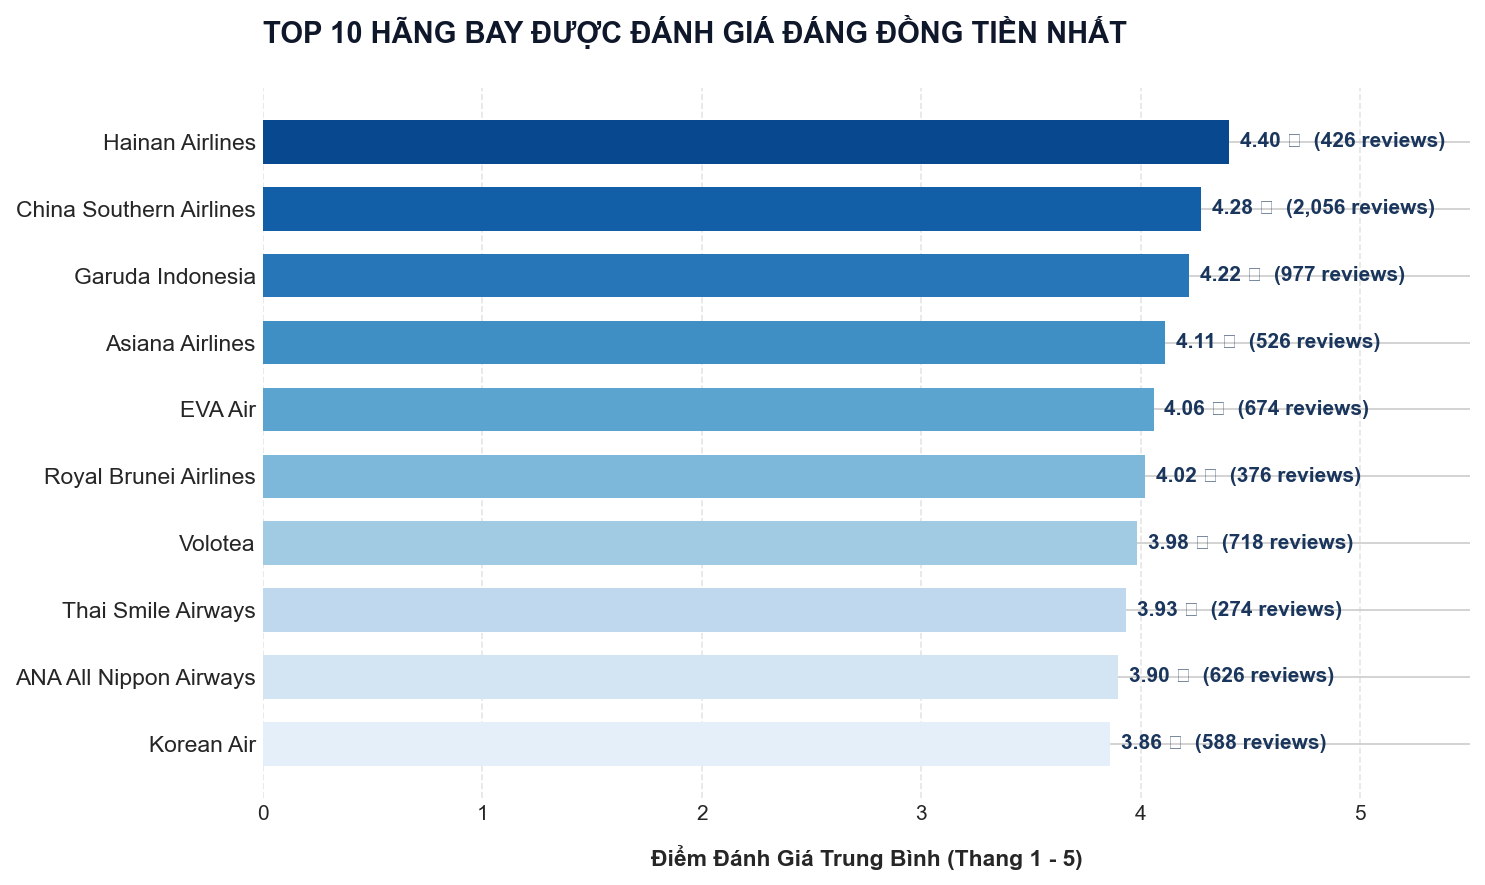

In [16]:
# 1. Thiết lập giao diện hiện đại, tinh gọn
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

# Sắp xếp lại để hãng điểm cao nhất nằm ở trên cùng
df_plot = top_10.sort_values(by='Avg', ascending=True).copy()

# 2. Vẽ biểu đồ thanh ngang
# Tạo dải màu gradient (hãng top càng cao màu càng đậm)
colors = sns.color_palette("Blues", n_colors=len(df_plot))
bars = ax.barh(df_plot['airline_name'], df_plot['Avg'], color=colors, height=0.65, edgecolor='none')

# 3. Thêm nhãn điểm số + số lượt đánh giá ngay đuôi mỗi thanh
for bar, avg, rating in zip(bars, df_plot['Avg'], df_plot['Rating']):
    width = bar.get_width()
    ax.text(
        width + 0.05, 
        bar.get_y() + bar.get_height() / 2, 
        f"{avg:.2f} ★  ({rating:,} reviews)", 
        ha='left', 
        va='center', 
        fontsize=10, 
        fontweight='bold', 
        color='#1a365d'
    )

# 4. Tinh chỉnh trục và giới hạn
ax.set_xlim(0, 5.5)   # Thang điểm 5, chừa khoảng trống cho nhãn
ax.set_xlabel("Điểm Đánh Giá Trung Bình (Thang 1 - 5)", fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel("")      # Bỏ nhãn trục Y vì tên hãng đã rất rõ
ax.tick_params(axis='y', labelsize=11)

# 5. Tiêu đề chính và phụ dành cho báo cáo cấp quản lý
plt.title(
    "TOP 10 HÃNG BAY ĐƯỢC ĐÁNH GIÁ ĐÁNG ĐỒNG TIỀN NHẤT\n", 
    fontsize=14, 
    fontweight='bold', 
    loc='left', 
    color='#0f172a'
)
# plt.suptitle(
#     "Dữ liệu Skytrax | Tiêu chí: Value for Money | Điều kiện: Ít nhất 100 lượt đánh giá", 
#     fontsize=10, 
#     color='#64748b', 
#     x=0.125, 
#     y=0.94, 
#     ha='left'
# )

# 6. Loại bỏ khung viền thừa để biểu đồ thoáng mắt
sns.despine(left=True, bottom=True)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()

# 7. Tự động lưu thành ảnh chất lượng cao để chèn vào Slide PowerPoint
plt.savefig("top_10_airlines_value_for_money.png", dpi=300, bbox_inches='tight')
print("✅ Đã lưu ảnh sắc nét vào file: top_10_airlines_value_for_money.png")

plt.show()


Em ơi, anh cần một con số để mở đầu slide tổng quan cho khách: toàn bộ kho dữ liệu đang có bao nhiêu lượt đánh giá chuyến bay của hành khách? Một con số duy nhất thôi.

- Chief Insights Officer, cần trước 9h sáng mai

In [17]:
# #CIO
# #Total_airline_review_rating

# def count_airline_review():
#     return len(airline_reviews)

# print(f'Total airline review: {count_airline_review()}')

    

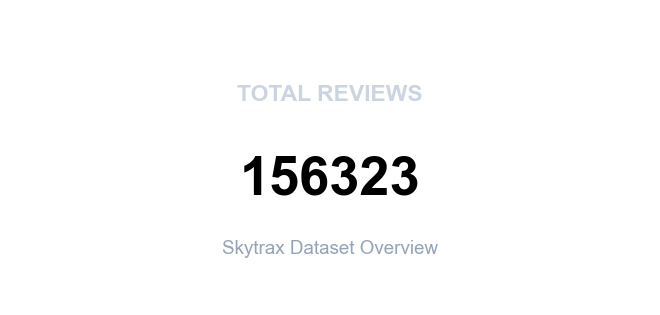

In [18]:
def plot_kpi_box():
    total_reviews = len(airline_reviews)
    
    fig, ax = plt.subplots(figsize=(4.5, 2.2), dpi=150)
    ax.set_facecolor('#f8fafc')
    fig.patch.set_facecolor('#ffffff')
    
    # Vẽ khung bo góc
    bbox_props = dict(boxstyle="round,pad=1,rounding_size=0.3", fc="#1e3c72", ec="none")
    ax.text(0.5, 0.5, '', transform=ax.transAxes, bbox=bbox_props, ha='center', va='center')
    
    # Tiêu đề KPI
    ax.text(0.5, 0.72, 'TOTAL REVIEWS', transform=ax.transAxes,
            ha='center', va='center', fontsize=11, color='#cbd5e1', weight='bold')
    
    # Số liệu chính
    ax.text(0.5, 0.42, f'{total_reviews}', transform=ax.transAxes,
            ha='center', va='center', fontsize=26, color='#000000', weight='bold')
    
    # Subtitle / Ghi chú nhỏ
    ax.text(0.5, 0.18, 'Skytrax Dataset Overview', transform=ax.transAxes,
            ha='center', va='center', fontsize=9, color='#94a3b8')
    
    ax.axis('off')
    plt.tight_layout()
    # plt.savefig('kpi_total_reviews.png', dpi=300, bbox_inches='tight')  # Mở nếu cần lưu ảnh
    plt.show()

plot_kpi_box()


Chị đang chốt phạm vi báo cáo. Em đếm nhanh giúp chị có bao nhiêu hãng bay khác nhau từng xuất hiện trong các đánh giá chuyến bay? Chị chỉ cần một con số.

- VP Customer Experience


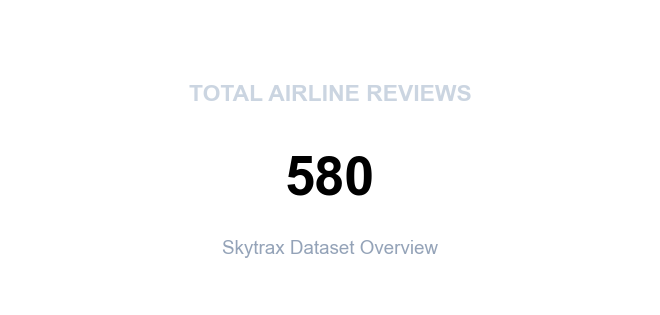

In [19]:
#Count airline 
def plot_kpi_box():
    total_review_airline = airline_reviews['airline_id'].nunique()
    
    fig, ax = plt.subplots(figsize=(4.5, 2.2), dpi=150)
    ax.set_facecolor('#f8fafc')
    fig.patch.set_facecolor('#ffffff')
    
    # Vẽ khung bo góc
    bbox_props = dict(boxstyle="round,pad=1,rounding_size=0.3", fc="#1e3c72", ec="none")
    ax.text(0.5, 0.5, '', transform=ax.transAxes, bbox=bbox_props, ha='center', va='center')
    
    # Tiêu đề KPI
    ax.text(0.5, 0.72, 'TOTAL AIRLINE REVIEWS', transform=ax.transAxes,
            ha='center', va='center', fontsize=11, color='#cbd5e1', weight='bold')
    
    # Số liệu chính
    ax.text(0.5, 0.42, f'{total_review_airline}', transform=ax.transAxes,
            ha='center', va='center', fontsize=26, color='#000000', weight='bold')
    
    # Subtitle / Ghi chú nhỏ
    ax.text(0.5, 0.18, 'Skytrax Dataset Overview', transform=ax.transAxes,
            ha='center', va='center', fontsize=9, color='#94a3b8')
    
    ax.axis('off')
    plt.tight_layout()
    # plt.savefig('kpi_total_reviews.png', dpi=300, bbox_inches='tight')  # Mở nếu cần lưu ảnh
    plt.show()

plot_kpi_box()


Anh cần chỉ số 'thiện cảm' cho slide đầu tiên: trong tất cả đánh giá chuyến bay, bao nhiêu phần trăm hành khách nói rằng họ sẽ giới thiệu hãng cho người khác? Một con số phần trăm.

- VP Customer Experience, họp với hãng chiều nay

In [20]:
#recommended
recommendation_rate= airline_reviews['recommended'].mean()*100
print(f"Tỷ lệ giới thiệu (Recommendation Rate): {recommendation_rate:.1f}%")

Tỷ lệ giới thiệu (Recommendation Rate): 37.5%


Em ơi, team muốn biết tiếng nói đang đến từ thị trường nào. Cho anh 10 quốc tịch để lại nhiều đánh giá chuyến bay nhất, kèm số lượt của mỗi quốc tịch, xếp từ nhiều xuống ít.

- Head of Market Research

In [21]:
# top 10 nationality airline review (counter and desc)
# Mục đích: 

def top_10_nationality():
    nationality = airline_reviews['nationality'].value_counts().head(10).reset_index()
    return nationality
display(top_10_nationality())



,nationality,count
0,United States,51232
1,United Kingdom,24949
2,Australia,13424
3,Canada,12769
4,Germany,4243
5,India,3705
6,Singapore,2421
7,Netherlands,2300
8,France,2125
9,New Zealand,1781


Chị cần một con số benchmark cho khâu ghế ngồi: điểm trung bình mà hành khách chấm cho mức độ thoải mái của ghế trên toàn bộ đánh giá chuyến bay là bao nhiêu? Một con số là đủ.

- Product Lead Cabin

In [22]:
print(f'Column list of seat_reviews {seat_reviews.columns}')

seat_reviews.head(5)

Column list of seat_reviews Index(['review_id', 'airline_id', 'type_of_traveller', 'seat_type',
       'aircraft_type', 'seat_layout', 'verify', 'date_submitted',
       'date_flown', 'customer_name', 'nationality', 'seat_legroom',
       'seat_recline', 'seat_width', 'aisle_space', 'seat_storage',
       'power_supply', 'viewing_tv_screen', 'sleep_comfort', 'sitting_comfort',
       'seat_bed_width', 'seat_bed_length', 'seat_privacy', 'recommended',
       'review', 'updated_at'],
      dtype='object')


,review_id,airline_id,type_of_traveller,seat_type,aircraft_type,seat_layout,verify,date_submitted,date_flown,customer_name,...,power_supply,viewing_tv_screen,sleep_comfort,sitting_comfort,seat_bed_width,seat_bed_length,seat_privacy,recommended,review,updated_at
0,1,17,Couple Leisure,Economy Class,Boeing 737-800,3x3,True,2023-08-26,2023-08-01,Carol Costa 29,...,2.0,2.0,NaN,NaN,NaN,NaN,NaN,False,The seats on the way to Cancun from Mexico Cit...,2026-06-20 12:45:41
1,2,17,Solo Leisure,Economy Class,Boeing 737-800,3x3,True,2022-03-15,2022-03-01,Laura Patel 28,...,NaN,2.0,NaN,NaN,NaN,NaN,NaN,False,"Seats are hard as a rock, slanting downwards, ...",2026-06-20 12:45:41
2,3,17,Business,Economy Class,Boeing 787-9,3x3x3,True,2019-06-26,2019-06-01,Mary Adams 31,...,4.0,5.0,NaN,NaN,NaN,NaN,NaN,True,It was my first experience on a 9-abreast Drea...,2026-06-20 12:45:41
3,4,17,Family Leisure,Premium Economy,Boeing 737-800,3x3,True,2018-09-29,2018-09-01,Michael Smith 4,...,5.0,5.0,NaN,NaN,NaN,NaN,NaN,True,"Good leg space and recline on AM Plus seats, a...",2026-06-20 12:45:41
4,5,17,Couple Leisure,Economy Class,Boeing 737-800,3x3,True,2018-09-10,2018-09-01,Christopher Smith 3,...,5.0,5.0,NaN,NaN,NaN,NaN,NaN,True,"Main Cabin Seat 24A, window. Good recline, goo...",2026-06-20 12:45:41


In [23]:
Total_score = airline_reviews['seat_comfort'].count()
print(f'Total Score: {Total_score}')

avg= airline_reviews['seat_comfort'].mean()
print(f'Trung bình: {avg}') 

Total Score: 140098
Trung bình: 2.7122871133063997


Chị nghi khách công vụ và khách du lịch cảm nhận rất khác nhau. Em giúp chị: với mỗi nhóm hành khách, tỷ lệ sẵn sàng giới thiệu là bao nhiêu? Output mỗi dòng một nhóm khách, kèm số lượt đánh giá và tỷ lệ phần trăm.

- VP Customer Experience


In [24]:
# Gán Business
airline_reviews.loc[airline_reviews['type_of_traveller'] == 'Business', 'traveller_group'] = 'Business'
# Gán các nhóm Leisure
leisure_types = ['Solo Leisure', 'Couple Leisure', 'Family Leisure']
airline_reviews.loc[airline_reviews['type_of_traveller'].isin(leisure_types), 'traveller_group'] = 'Leisure'

In [30]:
airline_reviews.head(5)

,review_id,airline_id,verify,date_submitted,date_flown,customer_name,nationality,type_of_traveller,seat_type,aircraft,...,cabin_staff_service,food_and_beverages,inflight_entertainment,ground_service,wifi_and_connectivity,value_for_money,recommended,review,updated_at,traveller_group
0,1,313,False,2002-01-06,None,Joshua Torres 6,flt. 93,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,False,I flew Lan Peru on a domestic flight from Lima...,2026-04-03 14:30:19,Unknown
1,2,313,False,2002-01-06,None,Joshua Torres 6,flt. 93,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,False,I flew Lan Peru on a domestic flight from Lima...,2026-04-03 14:30:19,Unknown
2,3,466,False,2002-02-14,None,Cynthia Lee 30,None,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Skymark is a low-fare airline in Japan. I flow...,2026-04-03 14:30:19,Unknown
3,4,313,False,2002-03-21,None,Donna Lee 9,thin around 40 about 5'5' dark hair to his sho...,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,False,I have flown LanPeru into and out of Cuzco man...,2026-04-03 14:30:19,Unknown
4,5,313,False,2002-03-21,None,Donna Lee 9,thin around 40 about 5'5' dark hair to his sho...,None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,False,I have flown LanPeru into and out of Cuzco man...,2026-04-03 14:30:19,Unknown


In [35]:
# Clean null 
# df['column_name'].fillna('Missing', inplace=True)
airline_reviews['recommended']= airline_reviews['recommended'].fillna('Unknown')
airline_reviews['recommended']= airline_reviews['recommended'].replace({
    True : 'Yes', False: 'No'
})

airline_reviews['traveller_group']= airline_reviews['traveller_group'].fillna('Unknown')

In [36]:
df_grouped = (
    airline_reviews
    .groupby(['traveller_group', 'recommended'])
    .size()
    .reset_index(name='count')
)

df_grouped['percentage'] = (
    df_grouped['count'] / 
    df_grouped.groupby('traveller_group')['count'].transform('sum') * 100
)
# 4. Hiển thị
for _, row in df_grouped.iterrows():
    print(f"- Nhóm {row['traveller_group']} | Trạng thái: {row['recommended']} | Số lượng: {row['count']:,} ({row['percentage']:.2f}%)")


- Nhóm Business | Trạng thái: No | Số lượng: 12,296 (68.91%)
- Nhóm Business | Trạng thái: Yes | Số lượng: 5,548 (31.09%)
- Nhóm Leisure | Trạng thái: No | Số lượng: 67,030 (67.68%)
- Nhóm Leisure | Trạng thái: Yes | Số lượng: 32,003 (32.32%)
- Nhóm Unknown | Trạng thái: No | Số lượng: 18,435 (46.73%)
- Nhóm Unknown | Trạng thái: Yes | Số lượng: 21,011 (53.27%)


In [39]:
# --- BẢNG 1: Bảng đếm số lượng (Counts) ---
table_1_counts = pd.crosstab(
    airline_reviews['traveller_group'], 
    airline_reviews['recommended'], 
    margins=True, 
    margins_name="Total"
)

# --- BẢNG 2: Bảng tỷ lệ phần trăm (% theo từng dòng) ---
table_2_pct = (
    pd.crosstab(
        airline_reviews['traveller_group'], 
        airline_reviews['recommended'], 
        normalize='index'
    ) * 100
).round(2)

# --- BẢNG 3: Bảng tóm tắt KPI cho VP Customer Experience ---
# Tính trên những khách thực sự đánh giá (loại Unknown nếu muốn số chuẩn)
table_3_kpi = (
    airline_reviews[airline_reviews['recommended'] != 'Unknown']
    .groupby('traveller_group')
    .agg(
        Tong_Danh_Gia=('recommended', 'count'),
        So_Luot_Yes=('recommended', lambda x: (x == 'Yes').sum()),
        Ty_Le_San_Sang_Gioi_Thieu=('recommended', lambda x: f"{(x == 'Yes').mean() * 100:.2f}%")
    )
    .reset_index()
)

# Hiển thị 3 bảng ra màn hình
print("=== BẢNG 1: SỐ LƯỢNG ĐÁNH GIÁ (COUNTS) ===")
display(table_1_counts)
print("\n=== BẢNG 2: TỶ LỆ PHÂN BỔ % THEO NHÓM ===")
display(table_2_pct)
print("\n=== BẢNG 3: TỔNG KẾT TỶ LỆ SẴN SÀNG GIỚI THIỆU (GỬI SẾP) ===")
display(table_3_kpi)


=== BẢNG 1: SỐ LƯỢNG ĐÁNH GIÁ (COUNTS) ===


recommended,No,Yes,Total
traveller_group,,,
Business,12296,5548,17844
Leisure,67030,32003,99033
Unknown,18435,21011,39446
Total,97761,58562,156323



=== BẢNG 2: TỶ LỆ PHÂN BỔ % THEO NHÓM ===


recommended,No,Yes
traveller_group,,
Business,68.91,31.09
Leisure,67.68,32.32
Unknown,46.73,53.27



=== BẢNG 3: TỔNG KẾT TỶ LỆ SẴN SÀNG GIỚI THIỆU (GỬI SẾP) ===


,traveller_group,Tong_Danh_Gia,So_Luot_Yes,Ty_Le_San_Sang_Gioi_Thieu
0,Business,17844,5548,31.09%
1,Leisure,99033,32003,32.32%
2,Unknown,39446,21011,53.27%


Anh đang làm việc với mấy cụm cảng. Cho anh 10 sân bay bị hành khách chấm tệ nhất ở khâu thời gian xếp hàng (điểm trung bình thấp nhất), chỉ xét sân bay có từ 50 lượt đánh giá trở lên. Gửi anh tên sân bay + điểm trung bình + số lượt.

- Head of Airport Relations

In [46]:
airport_reviews.columns


Index(['review_id', 'airport_id', 'verify', 'date_submitted', 'date_visit',
       'customer_name', 'nationality', 'experience_at_airport',
       'type_of_traveller', 'queuing_times', 'terminal_cleanliness',
       'terminal_seating', 'terminal_signs', 'food_beverages',
       'airport_shopping', 'airport_staff', 'wifi_connectivity', 'recommended',
       'review', 'updated_at'],
      dtype='object')

In [53]:
merge_airport_review = pd.merge(airports, airport_reviews, on= 'airport_id', how='inner')
# Group theo sân bay và tính điểm trung bình 

airport_queing_kpi = (merge_airport_review.groupby('airport_name')['queuing_times'].agg(
    avg='mean',
    rating='count'
    ).reset_index()
    )

# 3:

queing_filter= airport_queing_kpi[airport_queing_kpi['rating']>=50]

top_10_worst_queuing = (
    queing_filter.sort_values(by='avg',
    ascending=True).head(10).reset_index(drop=True)
)

# Làm tròn điểm trung bình 2 chữ số thập phân
top_10_worst_queuing['avg'] = top_10_worst_queuing['avg'].round(2)

# --- HIỂN THỊ KẾT QUẢ ---
print("=== TOP 10 SÂN BAY XẾP HÀNG TỆ NHẤT (>= 50 ĐÁNH GIÁ) ===")
display(top_10_worst_queuing)
print("\n--- ĐỊNH DẠNG VĂN BẢN GỬI SẾP ---")
for i, row in top_10_worst_queuing.iterrows():
    print(f"{i+1}. {row['airport_name']}: {row['avg']:.2f} điểm ({row['rating']:,} lượt đánh giá)")


=== TOP 10 SÂN BAY XẾP HÀNG TỆ NHẤT (>= 50 ĐÁNH GIÁ) ===


,airport_name,avg,rating
0,Grenoble,1.11,71
1,Berlin Brandenburg,1.46,210
2,Lyon,1.57,130
3,Beauvais,1.61,85
4,London Stansted,1.62,899
5,Heraklion,1.64,146
6,Bordeaux,1.64,186
7,Geneva,1.66,276
8,Luton,1.66,782
9,Berlin Schonefeld,1.71,158



--- ĐỊNH DẠNG VĂN BẢN GỬI SẾP ---
1. Grenoble: 1.11 điểm (71 lượt đánh giá)
2. Berlin Brandenburg: 1.46 điểm (210 lượt đánh giá)
3. Lyon: 1.57 điểm (130 lượt đánh giá)
4. Beauvais: 1.61 điểm (85 lượt đánh giá)
5. London Stansted: 1.62 điểm (899 lượt đánh giá)
6. Heraklion: 1.64 điểm (146 lượt đánh giá)
7. Bordeaux: 1.64 điểm (186 lượt đánh giá)
8. Geneva: 1.66 điểm (276 lượt đánh giá)
9. Luton: 1.66 điểm (782 lượt đánh giá)
10. Berlin Schonefeld: 1.71 điểm (158 lượt đánh giá)
